Classical baseline: band-power features + Ridge regression

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import welch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

from train_cv import make_stratified_folds, _load_pca_and_subjects

In [2]:
# ── Config — mirrors train_cv.py defaults for comparability ──────────────────
DATA_DIR    = Path("model_data/non_ica_19_channels")
PCA_PARQUET = Path("model_data/matched_pca_vectors.parquet")
OUTPUT_DIR  = Path("model_data/baseline_band_power_results")
FEATURE_CACHE = OUTPUT_DIR / "band_power_features.parquet"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SFREQ    = 256
SEG_LEN  = 2560          
NPERSEG  = 512         
NOVERLAP = 256           

BANDS = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta":  (13, 30),
    "gamma": (30, 45),
}
TOTAL_BAND = (0.5, 45)

N_FOLDS    = 10
N_BINS     = 20
N_PCA      = 1
PCA_OFFSET = 0
SEED       = 42

In [3]:
def load_segments_array(path):
    """Return (channel_names sorted, arr[n_seg, n_ch, SEG_LEN]) for one subject parquet."""
    df = (pd.read_parquet(path, columns=["channel_name", "segment", "segment_index"])
            .sort_values(["segment_index", "channel_name"]))
    n_seg = df["segment_index"].nunique()
    n_ch  = df["channel_name"].nunique()
    channel_names = sorted(df["channel_name"].unique())
    arr = np.stack([
        np.pad(np.asarray(a, dtype=np.float64)[:SEG_LEN],
               (0, max(0, SEG_LEN - len(a))), mode="reflect")
        for a in df["segment"]
    ])
    arr = arr.reshape(n_seg, n_ch, SEG_LEN)
    return channel_names, arr


def extract_subject_band_power(path):
    """Return (channel_names, feature_vector) of log10 relative band power, len = n_ch * n_bands.
    Ordered channel-major, band-minor: [ch0_delta, ch0_theta, ..., ch1_delta, ...]
    """
    channel_names, arr = load_segments_array(path)
    freqs, psd = welch(arr, fs=SFREQ, nperseg=NPERSEG, noverlap=NOVERLAP, axis=-1)
    mean_psd = psd.mean(axis=0)  # average across segments in power domain, (n_ch, n_freqs)

    total_mask = (freqs >= TOTAL_BAND[0]) & (freqs <= TOTAL_BAND[1])
    total_power = mean_psd[:, total_mask].sum(axis=1)  # (n_ch,)

    band_feats = []
    for lo, hi in BANDS.values():
        mask = (freqs >= lo) & (freqs < hi)
        band_power = mean_psd[:, mask].sum(axis=1)          # (n_ch,)
        rel_power = band_power / (total_power + 1e-12)       # (n_ch,)
        band_feats.append(rel_power)
    band_feats = np.stack(band_feats, axis=1)  # (n_ch, n_bands)
    log_feats = np.log10(band_feats + 1e-8)
    return channel_names, log_feats.reshape(-1)  # flatten channel-major, band-minor

In [4]:
pca_vals, all_subjects = _load_pca_and_subjects(
    type("Args", (), {"pca_parquet": str(PCA_PARQUET), "data_dir": str(DATA_DIR)})
)
print(f"Total subjects: {len(all_subjects)}")

Total subjects: 1573


In [6]:
if FEATURE_CACHE.exists():
    feat_df = pd.read_parquet(FEATURE_CACHE).set_index("subject")
    print(f"Loaded cached features for {len(feat_df)} subjects from {FEATURE_CACHE}")
else:
    paths = {p.stem: p for p in DATA_DIR.glob("*.parquet")}
    rows, feature_cols, subj_ids = [], None, []
    for i, s in enumerate(all_subjects):
        channel_names, feats = extract_subject_band_power(paths[s])
        if feature_cols is None:
            band_names = list(BANDS.keys())
            feature_cols = [f"{ch}_{b}" for ch in channel_names for b in band_names]
        rows.append(feats)
        subj_ids.append(s)
        if (i + 1) % 50 == 0 or i + 1 == len(all_subjects):
            print(f"  extracted {i+1}/{len(all_subjects)}", flush=True)

    feat_df = pd.DataFrame(np.stack(rows), index=pd.Index(subj_ids, name="subject"), columns=feature_cols)
    feat_df.reset_index().to_parquet(FEATURE_CACHE, index=False)
    print(f"Saved feature cache → {FEATURE_CACHE}")

feat_df.shape

Loaded cached features for 1573 subjects from model_data/baseline_band_power_results/band_power_features.parquet


(1573, 95)

In [7]:
rng = np.random.default_rng(SEED)
folds, always_train = make_stratified_folds(all_subjects, pca_vals, N_FOLDS, N_BINS, rng)
holdout_sizes = [len(f) for f in folds]
print(f"Stratified folds: {N_FOLDS} folds x {N_BINS} PC1 bins → holdout sizes {holdout_sizes} "
      f"(always-train: {len(always_train)})")

Stratified folds: 10 folds x 20 PC1 bins → holdout sizes [20, 20, 20, 20, 20, 20, 20, 20, 20, 20] (always-train: 1373)


## CV loop: RidgeCV per fold

In [10]:
def get_targets(subject_ids):
    ids = [str(s) for s in subject_ids]
    raw = np.stack([
        pca_vals.loc[s].to_numpy(dtype=np.float64)[PCA_OFFSET:PCA_OFFSET + N_PCA]
        for s in ids
    ])
    return raw


def run_fold(fold_idx):
    test_subjects = folds[fold_idx]
    other_holdout = np.concatenate([folds[i] for i in range(N_FOLDS) if i != fold_idx])
    train_subjects = np.concatenate([other_holdout, always_train])

    X_train = feat_df.loc[[str(s) for s in train_subjects]].to_numpy()
    X_test  = feat_df.loc[[str(s) for s in test_subjects]].to_numpy()
    y_train = get_targets(train_subjects)
    y_test  = get_targets(test_subjects)

    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)

    # Ridge: nested alpha selection via built-in CV on the training pool
    ridge = RidgeCV(alphas=np.logspace(-3, 4, 29), cv=5)
    ridge.fit(X_train_s, y_train)
    # RidgeCV squeezes to 1D when there's a single target column; restore (n, N_PCA)
    pred_ridge = ridge.predict(X_test_s).reshape(y_test.shape)

    r2_ridge = r2_score(y_test, pred_ridge, multioutput="raw_values")
    print(f"Fold {fold_idx}  n_test={len(test_subjects)}  "
          f"ridge_alpha={ridge.alpha_:.4g}  R2 ridge={r2_ridge}")

    records = []
    for i, s in enumerate(test_subjects):
        records.append({
            "fold": fold_idx, "subject": str(s),
            "true_pc1": float(y_test[i, 0]),
            "pred_pc1_ridge": float(pred_ridge[i, 0]),
        })
    return records, r2_ridge

In [11]:
all_records, ridge_r2s = [], []
for fold_idx in range(N_FOLDS):
    records, r2_ridge = run_fold(fold_idx)
    all_records.extend(records)
    ridge_r2s.append(r2_ridge)

ridge_r2s = np.array(ridge_r2s)
print(f"\nRidge PC1 R²: {ridge_r2s[:, 0].mean():.4f} ± {ridge_r2s[:, 0].std():.4f}")

Fold 0  n_test=20  ridge_alpha=5623  R2 ridge=[0.13838863]
Fold 1  n_test=20  ridge_alpha=5623  R2 ridge=[0.07164107]
Fold 2  n_test=20  ridge_alpha=5623  R2 ridge=[0.02303951]
Fold 3  n_test=20  ridge_alpha=5623  R2 ridge=[0.17041068]
Fold 4  n_test=20  ridge_alpha=5623  R2 ridge=[0.10876296]
Fold 5  n_test=20  ridge_alpha=5623  R2 ridge=[-0.03769128]
Fold 6  n_test=20  ridge_alpha=5623  R2 ridge=[0.03236174]
Fold 7  n_test=20  ridge_alpha=5623  R2 ridge=[0.02800219]
Fold 8  n_test=20  ridge_alpha=5623  R2 ridge=[0.19385514]
Fold 9  n_test=20  ridge_alpha=5623  R2 ridge=[0.12279885]

Ridge PC1 R²: 0.0852 ± 0.0701


In [13]:
pred_df = pd.DataFrame(all_records)
pred_df.head()

,fold,subject,true_pc1,pred_pc1_ridge
0,0,224916425,-2.672112,-0.429500
1,0,359663557,-1.850256,-0.225979
2,0,898250050,-1.577484,-0.401860
3,0,926703685,-1.419616,-0.559746
4,0,130779853,-1.055053,-0.112131


Pooled holdout R² (across all folds):
  CNN (train_cv.py):     0.2782
  Ridge (band power):    0.0753


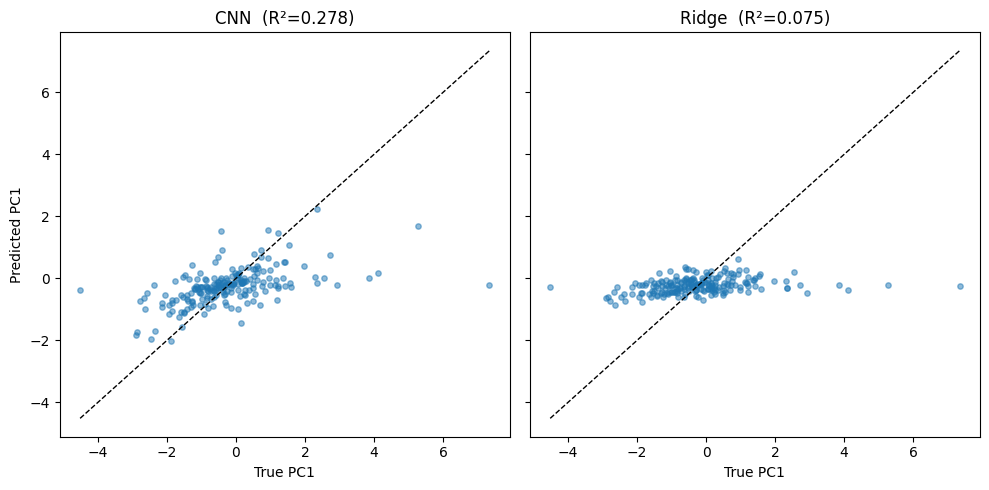

In [14]:
cnn_pred_path = Path("model_data/cv_results_stratified/predictions_1.parquet")
if cnn_pred_path.exists():
    cnn_df = pd.read_parquet(cnn_pred_path)
    cnn_r2 = r2_score(cnn_df["true_pc1"], cnn_df["pred_pc1"])
    ridge_r2_overall = r2_score(pred_df["true_pc1"], pred_df["pred_pc1_ridge"])
    print(f"Pooled holdout R² (across all folds):")
    print(f"  CNN (train_cv.py):     {cnn_r2:.4f}")
    print(f"  Ridge (band power):    {ridge_r2_overall:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
    for ax, (name, x, y, r2) in zip(axes, [
        ("CNN", cnn_df["true_pc1"], cnn_df["pred_pc1"], cnn_r2),
        ("Ridge", pred_df["true_pc1"], pred_df["pred_pc1_ridge"], ridge_r2_overall),
    ]):
        ax.scatter(x, y, alpha=0.5, s=15)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, 'k--', linewidth=1)
        ax.set_title(f"{name}  (R²={r2:.3f})")
        ax.set_xlabel("True PC1")
    axes[0].set_ylabel("Predicted PC1")
    plt.tight_layout()
    plt.show()
else:
    print(f"No CNN predictions found at {cnn_pred_path} — skipping comparison.")